# Time Series Evaluation Plots Examples

This notebook demonstrates how to use the TimeSeriesPlots class for forecasting evaluation. It covers actual-vs-predicted diagnostics, residual analysis, prediction interval visualization, and rolling error monitoring.

In [1]:
import importlib
import sys
from pathlib import Path

import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
if not (repo_root / "kvbiii_plots").exists():
    repo_root = Path("/home/kvbiii/Desktop/KubiK/Programming/Python/Paczki/kvbiii-plots")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import kvbiii_plots.evaluation.time_series_plots as time_series_plots_module
importlib.reload(time_series_plots_module)
TimeSeriesPlots = time_series_plots_module.TimeSeriesPlots

In [2]:
SEED = 42
N_POINTS = 96
FORECAST_START_INDEX = 72
FREQUENCY = "W"
BASE_LEVEL = 18.0
TREND_SLOPE = 0.13
SEASONAL_AMPLITUDE = 2.6
ACTUAL_NOISE_STD = 0.85
PREDICTION_NOISE_STD = 0.55
INTERVAL_HALF_WIDTH = 1.9
ROLLING_WINDOW = 8

## Generate Synthetic Forecasting Data

We build a realistic time series by combining trend, seasonality, and noise, then create model predictions and uncertainty bounds for evaluation plots.

In [3]:
np.random.seed(SEED)
time_index = pd.date_range(start="2023-01-01", periods=N_POINTS, freq=FREQUENCY)
time_steps = np.arange(N_POINTS)
trend_component = BASE_LEVEL + TREND_SLOPE * time_steps
seasonal_component = SEASONAL_AMPLITUDE * np.sin(2 * np.pi * time_steps / 12)
actual_noise = np.random.normal(loc=0.0, scale=ACTUAL_NOISE_STD, size=N_POINTS)
prediction_noise = np.random.normal(loc=0.0, scale=PREDICTION_NOISE_STD, size=N_POINTS)
y_true = trend_component + seasonal_component + actual_noise
y_pred = trend_component + seasonal_component + prediction_noise
lower_bound = y_pred - INTERVAL_HALF_WIDTH
upper_bound = y_pred + INTERVAL_HALF_WIDTH

print(f"Number of observations: {N_POINTS}")
print(f"Forecast starts at index: {FORECAST_START_INDEX}")
print(f"Date range: {time_index.min().date()} to {time_index.max().date()}")

Number of observations: 96
Forecast starts at index: 72
Date range: 2023-01-01 to 2024-10-27


In [4]:
time_series_eval_plots = TimeSeriesPlots()

print("Available metrics:", list(time_series_eval_plots.metrics_dict.keys()))
print("Default time-series colors:", time_series_eval_plots.default_time_series_colors)

Available metrics: ['Accuracy', 'Balanced Accuracy', 'F1', 'F1 (Micro)', 'F1 (Macro)', 'F1 (Weighted)', 'Recall', 'Precision', 'Roc AUC', 'MAE', 'MAPE', 'MSE', 'RMSE', 'RMSLE', 'R2']
Default time-series colors: {'actual': 'rgba(255, 167, 38, 0.98)', 'predicted': 'rgba(33, 150, 243, 0.98)', 'future_forecast': 'rgba(0, 121, 107, 0.98)', 'split_line': 'rgba(220, 53, 69, 0.95)', 'residual_positive': 'rgba(126, 189, 56, 0.95)', 'residual_negative': 'rgba(240, 84, 104, 0.95)', 'interval_line': 'rgba(47, 128, 237, 0.95)', 'interval_fill': 'rgba(47, 128, 237, 0.30)', 'rolling_error': 'rgba(28, 97, 180, 0.95)'}


## 1. plot_actual_vs_predicted_over_time()

This chart compares observed values with model predictions over time and highlights the forecast split point.

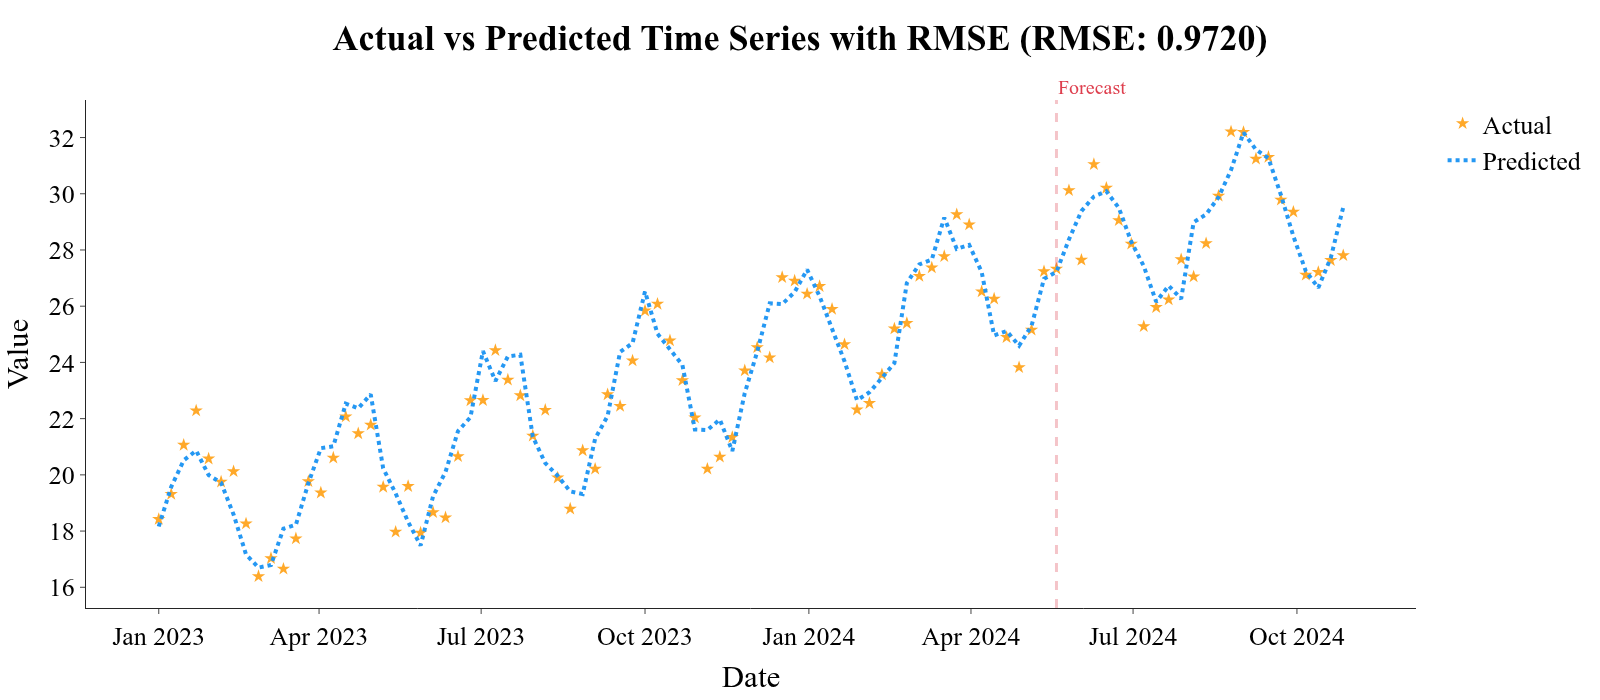

In [5]:
time_series_eval_plots.plot_actual_vs_predicted_over_time(
    y_true=y_true,
    y_pred=y_pred,
    time_index=time_index,
    split_point=FORECAST_START_INDEX,
    metric_name="RMSE",
    plot_title="Actual vs Predicted Time Series with RMSE"
)

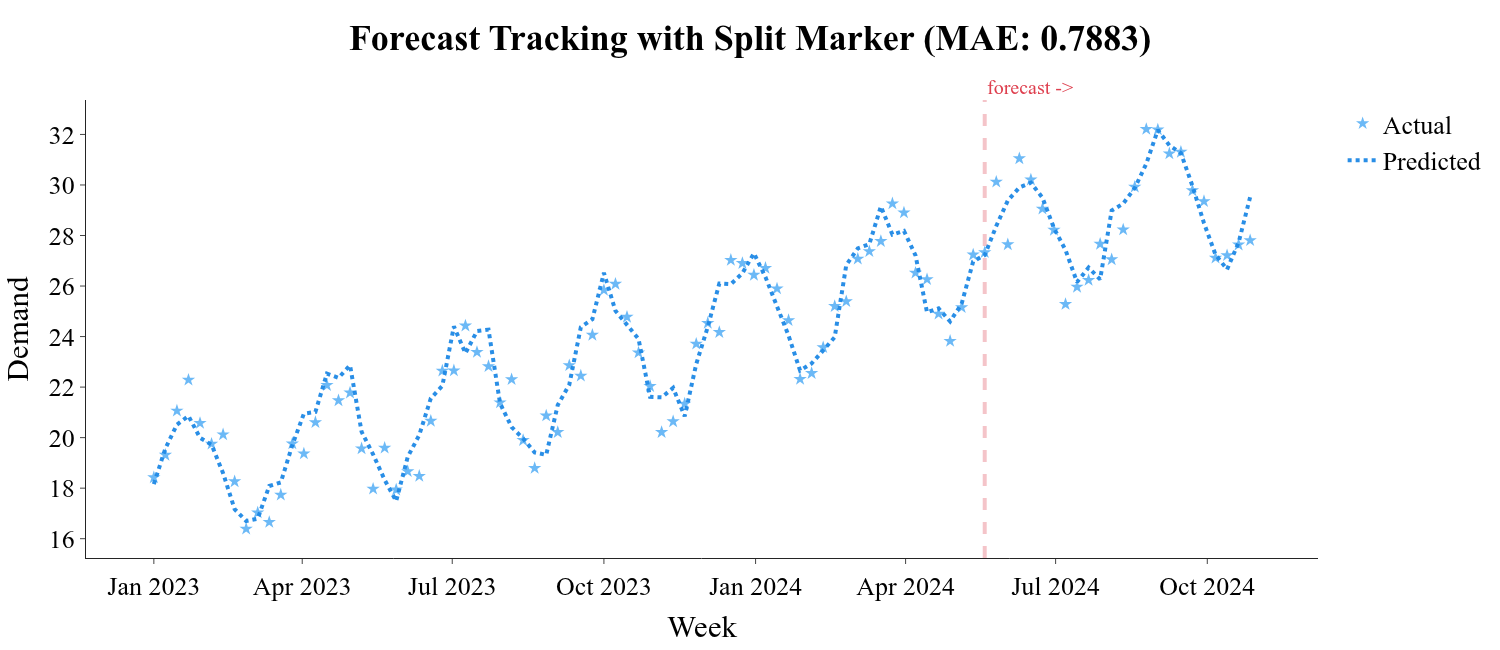

In [6]:
time_series_eval_plots.plot_actual_vs_predicted_over_time(
    y_true=y_true,
    y_pred=y_pred,
    time_index=time_index,
    plot_title="Forecast Tracking with Split Marker",
    width=1500,
    height=650,
    xaxis_title="Week",
    yaxis_title="Demand",
    metric_name="MAE",
    actual_color="rgba(100, 181, 246, 0.95)",
    predicted_color="rgba(30, 136, 229, 0.95)",
    split_point=time_index[FORECAST_START_INDEX],
    split_label="forecast ->",
    split_line_width=4,
)

## 2. plot_residuals_over_time()

Residual bars help identify temporal bias patterns and volatility shifts after the forecast start.

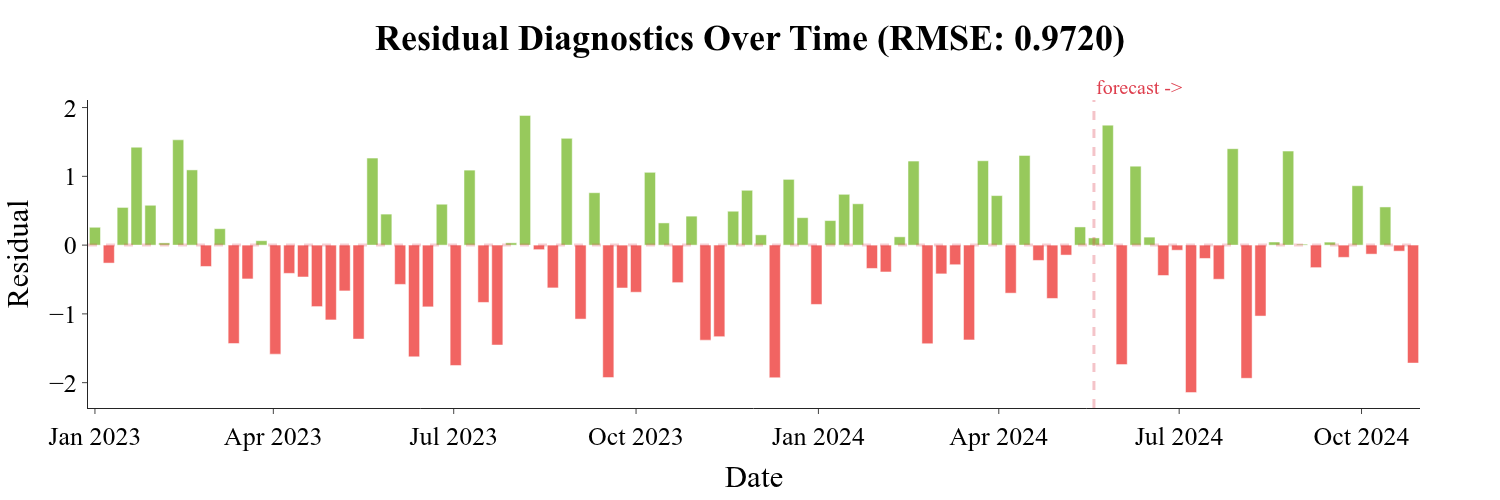

In [7]:
time_series_eval_plots.plot_residuals_over_time(
    y_true=y_true,
    y_pred=y_pred,
    time_index=time_index,
    plot_title="Residual Diagnostics Over Time",
    metric_name="RMSE",
    split_point=FORECAST_START_INDEX,
    split_label="forecast ->",
    positive_color="rgba(139, 195, 74, 0.95)",
    negative_color="rgba(239, 83, 80, 0.95)",
    zero_line_width=3,
    width=1500,
    height=500,
)

### Residual-Only Input Mode

You can pass precomputed residuals directly. This is useful when residuals are aggregated first, for example by day across many entities in panel data.

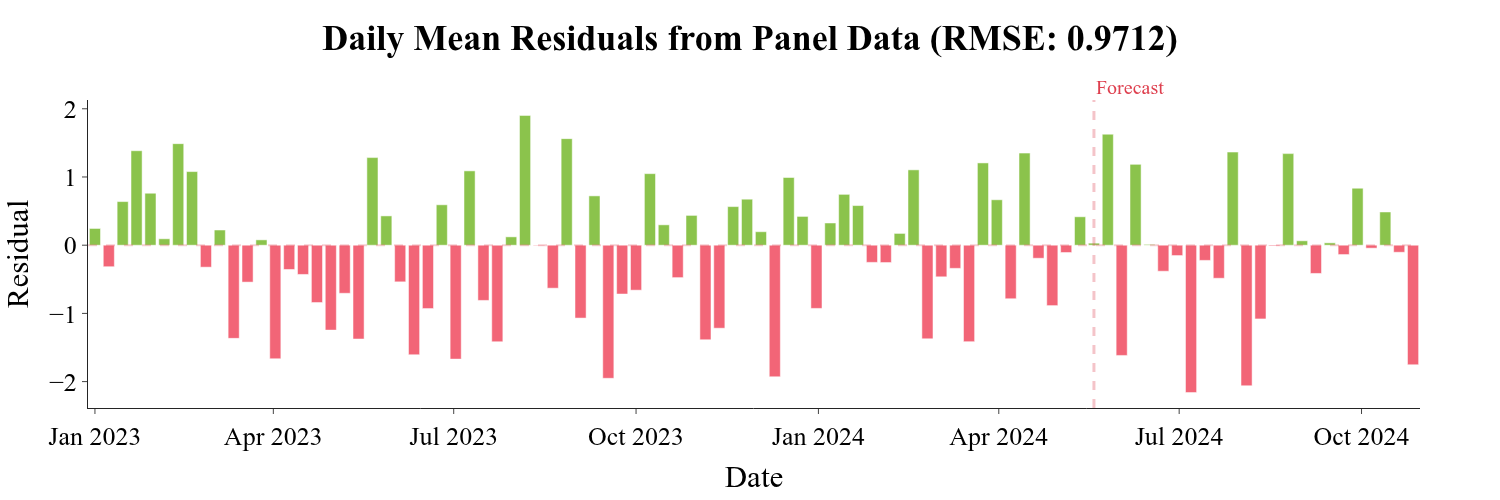

In [8]:
panel_residuals = pd.DataFrame({
    "date": np.repeat(time_index, 4),
    "entity": np.tile(["A", "B", "C", "D"], N_POINTS),
    "residual": np.repeat(y_true - y_pred, 4) + np.random.normal(0.0, 0.12, N_POINTS * 4),
})
daily_mean_residuals = panel_residuals.groupby("date", as_index=False)["residual"].mean()

time_series_eval_plots.plot_residuals_over_time(
    residuals=daily_mean_residuals["residual"].to_numpy(),
    time_index=daily_mean_residuals["date"].to_numpy(),
    metric_name="RMSE",
    plot_title="Daily Mean Residuals from Panel Data",
    split_point=FORECAST_START_INDEX,
    width=1500,
    height=500,
)

## 3. plot_prediction_interval_fan()

The fan-style interval plot combines forecast mean, uncertainty band, and optional actual values in one view.

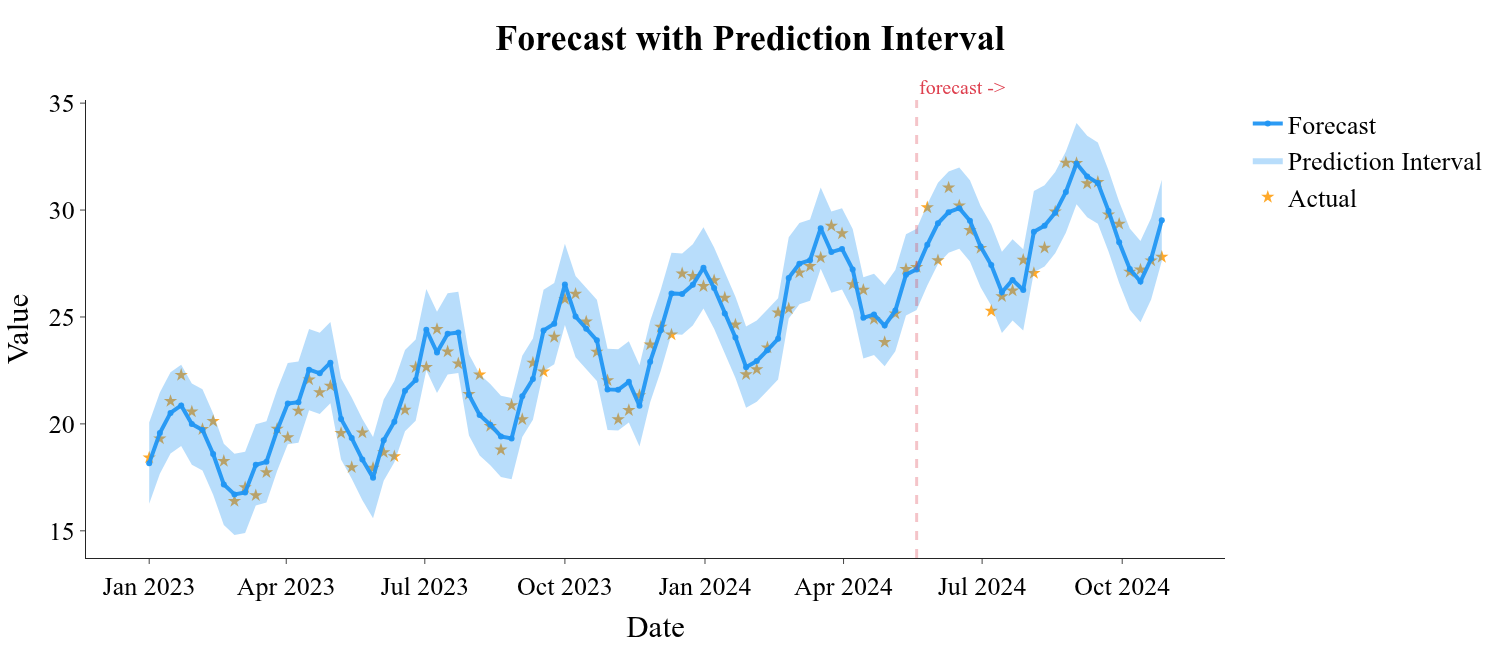

In [9]:
time_series_eval_plots.plot_prediction_interval_fan(
    y_pred=y_pred,
    time_index=time_index,
    lower_bound=lower_bound,
    upper_bound=upper_bound,
    y_true=y_true,
    plot_title="Forecast with Prediction Interval",
    split_point=FORECAST_START_INDEX,
    split_label="forecast ->",
    predicted_color="rgba(33, 150, 243, 0.95)",
    interval_fill_color="rgba(33, 150, 243, 0.32)",
    width=1500,
    height=650,
)

## 4. plot_rolling_error_over_time()

Rolling error curves reveal local performance drift and short-term stability of forecasts.

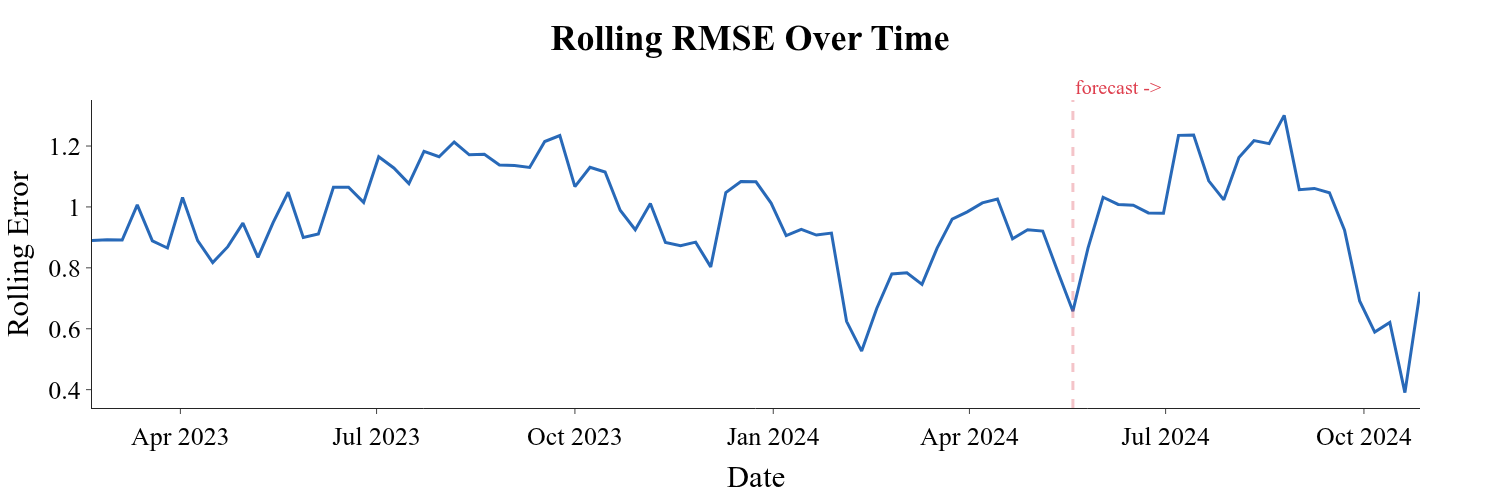

In [10]:
time_series_eval_plots.plot_rolling_error_over_time(
    y_true=y_true,
    y_pred=y_pred,
    time_index=time_index,
    rolling_window=ROLLING_WINDOW,
    rolling_metric="RMSE",
    split_point=FORECAST_START_INDEX,
    split_label="forecast ->",
    plot_title="Rolling RMSE Over Time",
    width=1500,
    height=500,
)

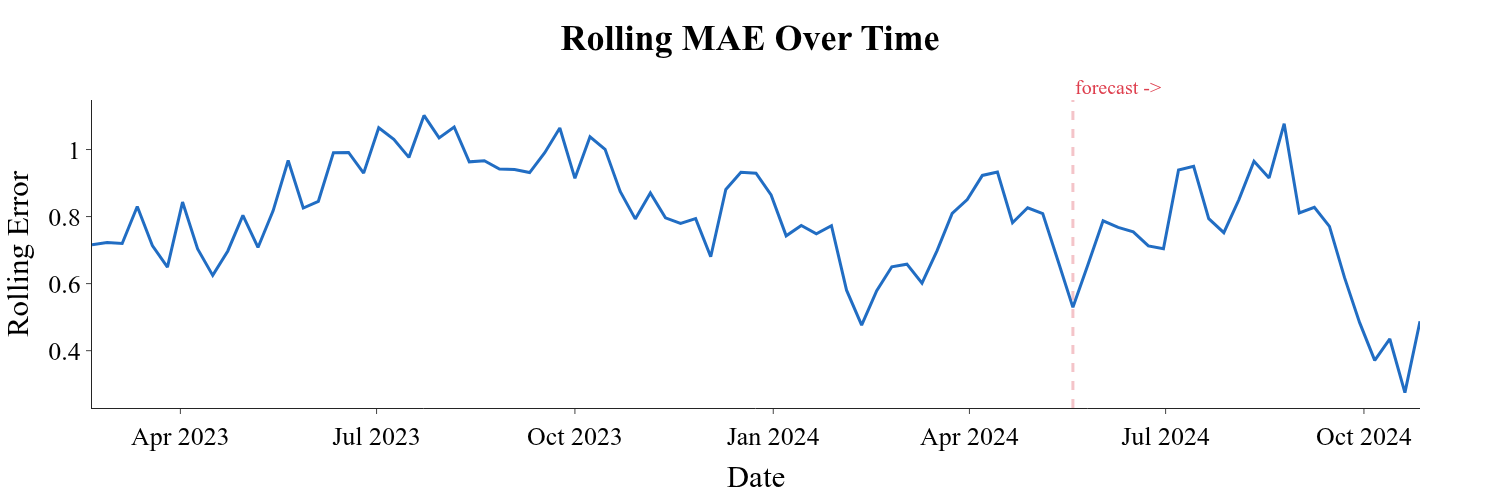

In [11]:
time_series_eval_plots.plot_rolling_error_over_time(
    y_true=y_true,
    y_pred=y_pred,
    time_index=time_index,
    rolling_window=ROLLING_WINDOW,
    rolling_metric="MAE",
    split_point=FORECAST_START_INDEX,
    split_label="forecast ->",
    plot_title="Rolling MAE Over Time",
    line_color="rgba(21, 101, 192, 0.95)",
    width=1500,
    height=500,
)

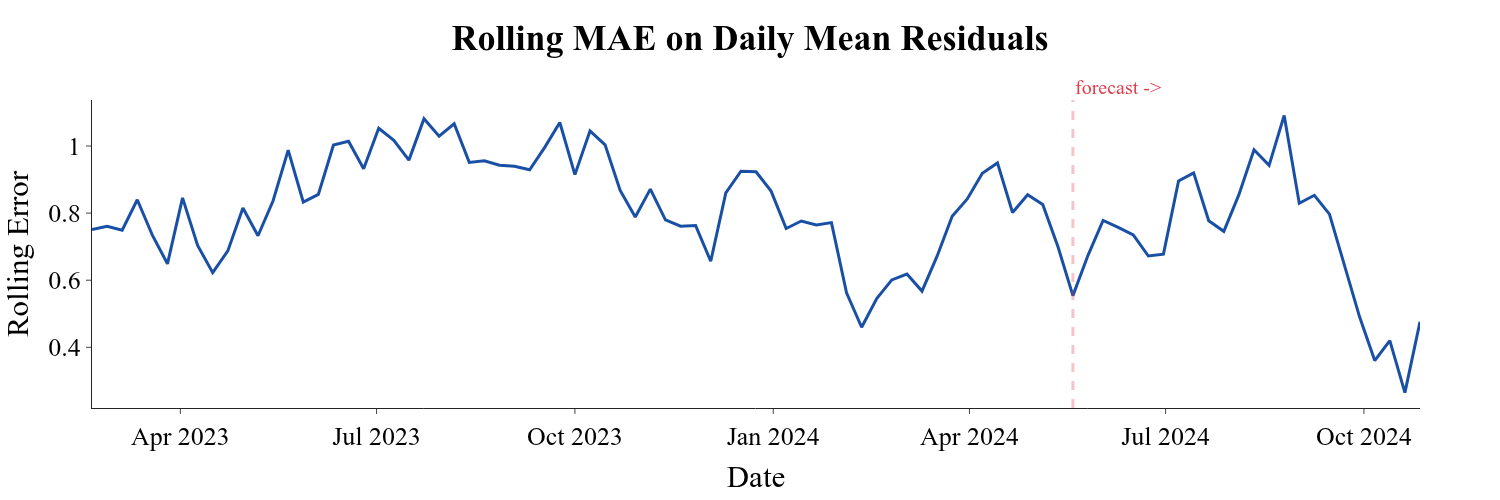

In [12]:
time_series_eval_plots.plot_rolling_error_over_time(
    residuals=daily_mean_residuals["residual"].to_numpy(),
    time_index=daily_mean_residuals["date"].to_numpy(),
    rolling_window=ROLLING_WINDOW,
    rolling_metric="MAE",
    split_point=FORECAST_START_INDEX,
    split_label="forecast ->",
    plot_title="Rolling MAE on Daily Mean Residuals",
    line_color="rgba(13, 71, 161, 0.95)",
    width=1500,
    height=500,
)

## 5. plot_historical_and_future_forecast()

This plot separates historical fit quality from future-only forecast values when future actual outcomes are not available yet.

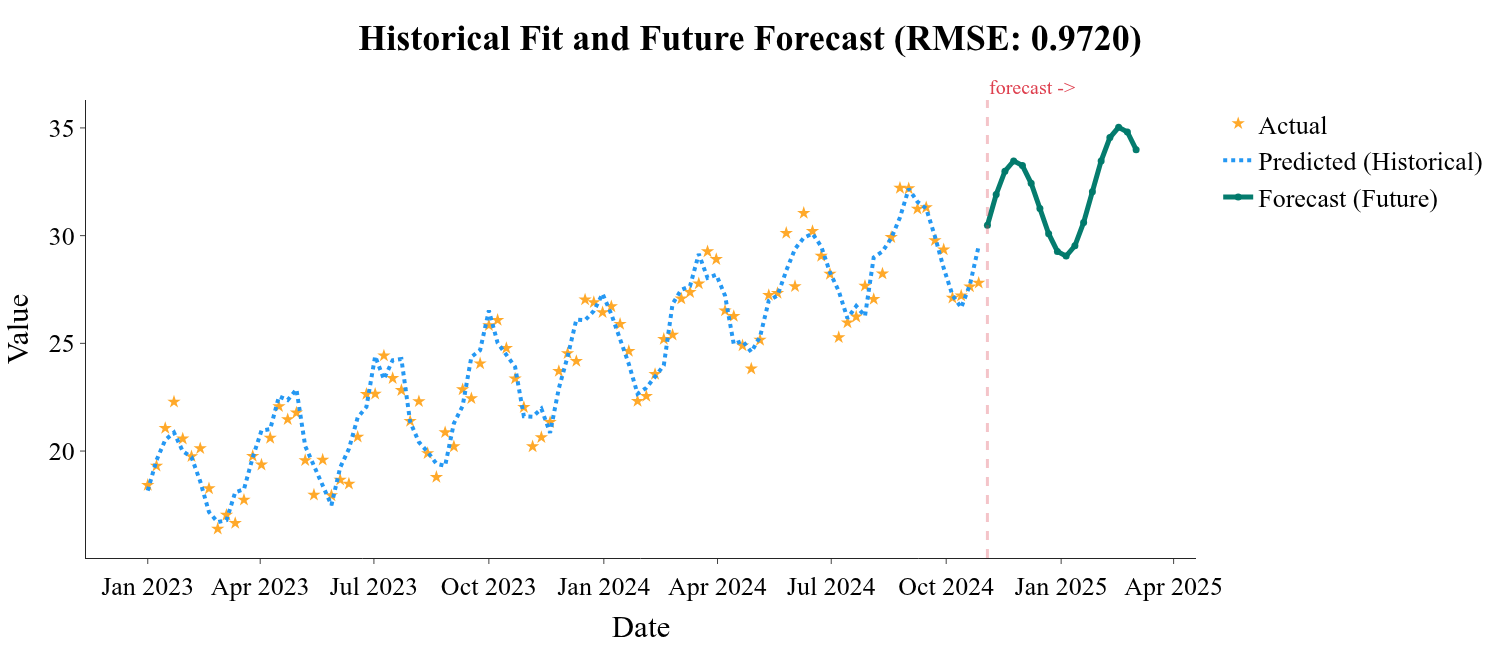

In [13]:
future_horizon = 18
future_time_index = pd.date_range(time_index[-1] + pd.Timedelta(weeks=1), periods=future_horizon, freq=FREQUENCY)
future_trend = trend_component[-1] + TREND_SLOPE * np.arange(1, future_horizon + 1)
future_seasonality = SEASONAL_AMPLITUDE * np.sin(2 * np.pi * np.arange(N_POINTS, N_POINTS + future_horizon) / 12)
future_forecast = future_trend + future_seasonality

time_series_eval_plots.plot_historical_and_future_forecast(
    y_true=y_true,
    y_pred=y_pred,
    y_forecast=future_forecast,
    historical_time_index=time_index,
    forecast_time_index=future_time_index,
    plot_title="Historical Fit and Future Forecast",
    metric_name="RMSE",
    split_label="forecast ->",
    width=1500,
    height=650,
)